# Create a simple Linear SVM model to classify if the user data is from the user or the other users

This is a simple benchmark to see if the user data is distinguishable from the other users.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark_dataset import (
    load_data_from_users,
    load_freq_phase
)

DATASET_ROOT_PATH = Path("/home/mateuschinelatto/Experiments/data/benchmark/")

In [9]:
# Configuration parameters
users = list(range(1, 36))
users_to_run = users.copy()

# Electrode indices for the electrodes Pz, PO5, PO3, POz, PO4, PO6, O1, Oz, O2
all_occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
# occipital_electrodes = [61]
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
# Which frequencies to analyze
all_frequencies, phases = load_freq_phase(DATASET_ROOT_PATH.joinpath("Freq_Phase.mat"))
print("All frequencies in the dataset:", all_frequencies)
bci_frequencies = all_frequencies[:8]
indices = [np.where(all_frequencies == freq)[0][0] for freq in bci_frequencies]

# Dataset visual delay and sampling frequency
visual_delay = 160 # ms
sample_rate = 250 # Hz

# Bandpass filter configuration
freq_cut_low = 6
freq_cut_high = 80
filter_order = 10

# Optional CAR configuration on loaded data
apply_car = True
car_reference_channels = all_occipital_electrodes
car_target_channels = occipital_electrodes

print("Users of interest:", users)
print("Users to run:", users_to_run)
print("BCI frequencies:", bci_frequencies)
print("Indices of frequencies of interest:", indices)

All frequencies in the dataset: [ 8.   9.  10.  11.  12.  13.  14.  15.   8.2  9.2 10.2 11.2 12.2 13.2
 14.2 15.2  8.4  9.4 10.4 11.4 12.4 13.4 14.4 15.4  8.6  9.6 10.6 11.6
 12.6 13.6 14.6 15.6  8.8  9.8 10.8 11.8 12.8 13.8 14.8 15.8]
Users of interest: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Users to run: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
BCI frequencies: [ 8.  9. 10. 11. 12. 13. 14. 15.]
Indices of frequencies of interest: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [10]:
window = 1.0

all_data_CAR_norm_1s = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=visual_delay,
    filter_bandpass=True,
    apply_car=True,
    car_reference_channels=car_reference_channels,
    car_target_channels=car_target_channels,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
    normalize=True,
    window_mode="single",
    window_size=sample_rate*window,
    window_overlap=0
)

all_data_CAR_1s = load_data_from_users(
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    users=users,
    visual_delay=visual_delay,
    filter_bandpass=True,
    apply_car=True,
    car_reference_channels=car_reference_channels,
    car_target_channels=car_target_channels,
    sample_rate=sample_rate,
    freq_cut_low=freq_cut_low,
    freq_cut_high=freq_cut_high,
    filter_order=filter_order,
    normalize=False,
    window_mode="single",
    window_size=sample_rate*window,
    window_overlap=0
)

print(all_data_CAR_norm_1s[0].shape)

Carregando dados dos usuarios:   0%|          | 0/35 [00:00<?, ?it/s]

Carregando dados dos usuarios: 100%|██████████| 35/35 [01:34<00:00,  2.70s/it]

(64, 250, 40, 6)


## Users

In [18]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np


def compute_domain_accuracy(data_target, data_source, classifier):
    """
    Compute cross-validated accuracy for distinguishing target-user data
    from source-user data.
    """
    X_target = data_target.reshape(data_target.shape[0], -1)
    X_source = data_source.reshape(data_source.shape[0], -1)

    y_target = np.zeros(X_target.shape[0])
    y_source = np.ones(X_source.shape[0])

    X = np.vstack((X_target, X_source))
    y = np.concatenate((y_target, y_source))

    scores = cross_val_score(classifier, X, y, cv=5, n_jobs=4)
    return np.mean(scores)


In [ ]:
from tqdm import tqdm
import csv
from ssvep_shared import build_tensors_no_cca, build_tensors_with_cca, build_tensors_with_fbcca

all_users_data = {}
for user in tqdm(users_to_run):
    print(f"Processing user {user}...")

    # Separar os dados do usuário atual (target) e os dados dos outros usuários (source)
    train_users = [u for u in users if u != user]
    train_data = np.concatenate(
        [all_data_CAR_norm_1s[users.index(u)] for u in train_users], axis=-1
    )
    test_data = all_data_CAR_norm_1s[users.index(user)]

    raw_train_data = np.concatenate(
        [all_data_CAR_1s[users.index(u)] for u in train_users], axis=-1
    )
    raw_test_data = all_data_CAR_1s[users.index(user)]

    x_train_user_raw, x_test_user_raw, labels_freq_train_user_raw, labels_freq_test_user_raw, channels_for_model_user_raw = (
        build_tensors_no_cca(
            raw_train_data,
            raw_test_data,
            occipital_electrodes,
            bci_frequencies,
            indices,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user, x_test_user, labels_freq_train_user, labels_freq_test_user, channels_for_model_user = (
        build_tensors_no_cca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            indices,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user_cca, x_test_user_cca, labels_freq_train_user_cca, labels_freq_test_user_cca, channels_for_model_user_cca = (
        build_tensors_with_cca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            phases,
            indices,
            3,
            0,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user_fbcca, x_test_user_fbcca, labels_freq_train_user_fbcca, labels_freq_test_user_fbcca, channels_for_model_user_fbcca = (
        build_tensors_with_fbcca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            phases,
            indices,
            3,
            0,
            250,
        )
    )

    svm = LinearSVC(max_iter=5000)
    logistic_regression = LogisticRegression(max_iter=5000, solver="liblinear")

    # Calcular a acurácia de separabilidade entre o usuário alvo e o grupo
    acc = {}
    for model_name, classifier in {
        "svm": svm,
        "logistic_regression": logistic_regression,
    }.items():
        acc[model_name] = {
            "no_cca": compute_domain_accuracy(x_test_user, x_train_user, classifier),
            "cca": compute_domain_accuracy(x_test_user_cca, x_train_user_cca, classifier),
            "fbcca": compute_domain_accuracy(x_test_user_fbcca, x_train_user_fbcca, classifier),
        }

    all_users_data[user] = acc

    print(
        f"User {user}: SVM = {acc['svm']['no_cca']:.4f}/{acc['svm']['cca']:.4f}/{acc['svm']['fbcca']:.4f}, "
        f"Logistic Regression = {acc['logistic_regression']['no_cca']:.4f}/"
        f"{acc['logistic_regression']['cca']:.4f}/{acc['logistic_regression']['fbcca']:.4f}"
    )

    with open("domain_accuracy_results.csv", mode="a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([
            user,
            acc["svm"]["no_cca"],
            acc["svm"]["cca"],
            acc["svm"]["fbcca"],
            acc["logistic_regression"]["no_cca"],
            acc["logistic_regression"]["cca"],
            acc["logistic_regression"]["fbcca"],
        ])


## Freqs

In [11]:
def compute_frequency_accuracy(x_train, x_test, y_train, y_test, classifier):
    """
    Compute accuracy for distinguishing ferquency classes.
    """
    X_train = x_train.reshape(x_train.shape[0], -1)
    X_test = x_test.reshape(x_test.shape[0], -1)

    classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    return score

In [12]:
from tqdm import tqdm
import csv
from ssvep_shared import build_tensors_no_cca, build_tensors_with_cca, build_tensors_with_fbcca

from sklearn.svm import LinearSVC

all_users_data = {}
for user in tqdm(users_to_run):
    print(f"Processing user {user}...")

    # Separar os dados do usuário atual (target) e os dados dos outros usuários (source)
    train_users = [u for u in users if u != user]

    train_data = np.concatenate(
        [all_data_CAR_norm_1s[users.index(u)] for u in train_users], axis=-1
    )
    test_data = all_data_CAR_norm_1s[users.index(user)]

    raw_train_data = np.concatenate(
        [all_data_CAR_1s[users.index(u)] for u in train_users], axis=-1
    )
    raw_test_data = all_data_CAR_1s[users.index(user)]

    x_train_user_raw, x_test_user_raw, labels_freq_train_user_raw, labels_freq_test_user_raw, channels_for_model_user_raw = (
        build_tensors_no_cca(
            raw_train_data,
            raw_test_data,
            occipital_electrodes,
            bci_frequencies,
            indices,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user, x_test_user, labels_freq_train_user, labels_freq_test_user, channels_for_model_user = (
        build_tensors_no_cca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            indices,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user_cca, x_test_user_cca, labels_freq_train_user_cca, labels_freq_test_user_cca, channels_for_model_user_cca = (
        build_tensors_with_cca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            phases,
            indices,
            5,
            0,
            250,
            apply_subband_filter=False,
        )
    )

    x_train_user_fbcca, x_test_user_fbcca, labels_freq_train_user_fbcca, labels_freq_test_user_fbcca, channels_for_model_user_fbcca = (
        build_tensors_with_fbcca(
            train_data,
            test_data,
            occipital_electrodes,
            bci_frequencies,
            phases,
            indices,
            5,
            0,
            250,
        )
    )

    svm = LinearSVC(max_iter=1000)
    acc = {
        "raw_no_cca": compute_frequency_accuracy(x_test_user_raw, x_train_user_raw, labels_freq_test_user_raw, labels_freq_train_user_raw, svm),
        "no_cca": compute_frequency_accuracy(x_test_user, x_train_user, labels_freq_test_user, labels_freq_train_user, svm),
        "cca": compute_frequency_accuracy(x_test_user_cca, x_train_user_cca, labels_freq_test_user_cca, labels_freq_train_user_cca, svm),
        "fbcca": compute_frequency_accuracy(x_test_user_fbcca, x_train_user_fbcca, labels_freq_test_user_fbcca, labels_freq_train_user_fbcca, svm),
    }
    all_users_data[user] = acc

    print(
        f"User {user}: SVM = {acc['no_cca']:.4f}/{acc['cca']:.4f}/{acc['fbcca']:.4f}"
    )

    with open("svm_results_all_90.csv", mode="a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([
            user,
            acc["raw_no_cca"],
            acc["no_cca"],
            acc["cca"],
            acc["fbcca"],

        ])


  0%|          | 0/35 [00:00<?, ?it/s]

Processing user 1...


  3%|▎         | 1/35 [00:04<02:26,  4.31s/it]

User 1: SVM = 0.3934/0.5870/0.5447
Processing user 2...


  6%|▌         | 2/35 [00:08<02:16,  4.14s/it]

...

User 33: SVM = 0.2230/0.3339/0.2996
Processing user 34...


 97%|█████████▋| 34/35 [02:23<00:04,  4.32s/it]

User 34: SVM = 0.2488/0.6078/0.5441
Processing user 35...


100%|██████████| 35/35 [02:27<00:00,  4.23s/it]

User 35: SVM = 0.3088/0.5018/0.4332


## SVM Results - Accuracy per User

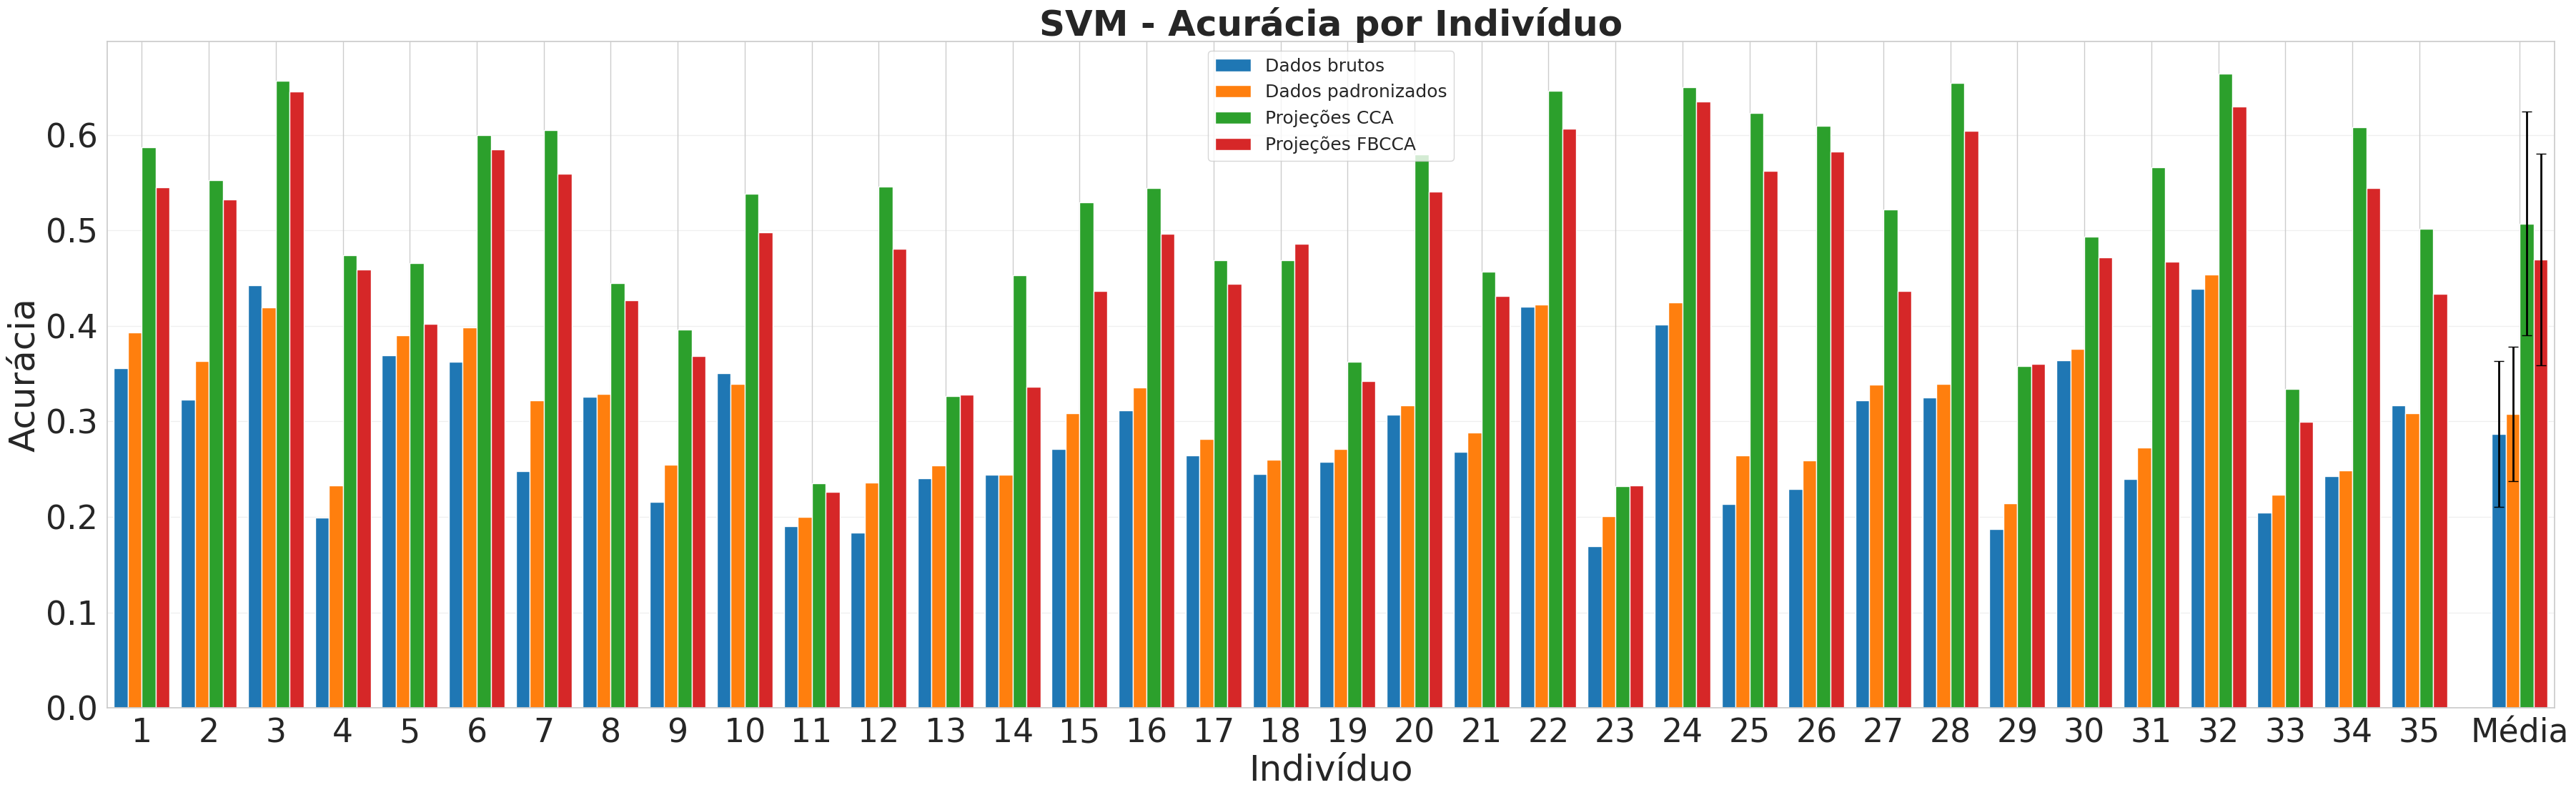

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=3, palette="tab10")

df = pd.read_csv("svm_results_all_90.csv", header=None,
                  names=["User", "Dados brutos", "Dados padronizados", "CCA", "FBCCA"])

means_dict = {col: df[col].mean() for col in ["Dados brutos", "Dados padronizados", "CCA", "FBCCA"]}
stds_dict = {col: df[col].std() for col in ["Dados brutos", "Dados padronizados", "CCA", "FBCCA"]}

spacing = 1.2
positions_users = np.arange(1, 36) * spacing
position_mean = positions_users[-1] + 1.5 * spacing

fig, ax = plt.subplots(figsize=(37, 12))

width = 0.25

ax.bar(positions_users - width*1.5, df["Dados brutos"], width, label="Dados brutos")
ax.bar(positions_users - width/2, df["Dados padronizados"], width, label="Dados padronizados")
ax.bar(positions_users + width/2, df["CCA"], width, label="Projeções CCA")
ax.bar(positions_users + width*1.5, df["FBCCA"], width, label="Projeções FBCCA")

ax.bar(position_mean - width*1.5, means_dict["Dados brutos"], width,
       color="C0", yerr=stds_dict["Dados brutos"], capsize=5, error_kw={"linewidth": 2})
ax.bar(position_mean - width/2, means_dict["Dados padronizados"], width,
       color="C1", yerr=stds_dict["Dados padronizados"], capsize=5, error_kw={"linewidth": 2})
ax.bar(position_mean + width/2, means_dict["CCA"], width,
       color="C2", yerr=stds_dict["CCA"], capsize=5, error_kw={"linewidth": 2})
ax.bar(position_mean + width*1.5, means_dict["FBCCA"], width,
       color="C3", yerr=stds_dict["FBCCA"], capsize=5, error_kw={"linewidth": 2})

ax.set_xlabel("Indivíduo")
ax.set_ylabel("Acurácia")
ax.set_title("SVM - Acurácia por Indivíduo", fontweight="bold")
ax.set_xticks(list(positions_users) + [position_mean])
ax.set_xticklabels([str(int(u)) for u in range(1, 36)] + ["Média"])
ax.legend(loc="best", fontsize=18)
ax.grid(axis="y", alpha=0.3)

# --- Corta as bordas: limita o eixo X ao espaço realmente usado pelas barras ---
margin = width * 2  # folga mínima pra não cortar a barra da ponta
ax.set_xlim(positions_users[0] - width*1.5 - margin/2,
            position_mean + width*1.5 + margin/2)

plt.tight_layout()
plt.show()

In [14]:
print(means_dict)
print(stds_dict)

{'Dados brutos': np.float64(0.2870973389355742), 'Dados padronizados': np.float64(0.308000700280112), 'CCA': np.float64(0.5071603641456581), 'FBCCA': np.float64(0.469485294117647)}
{'Dados brutos': np.float64(0.07633583408549016), 'Dados padronizados': np.float64(0.07031868455968839), 'CCA': np.float64(0.11696907427331972), 'FBCCA': np.float64(0.11089051237752785)}


## CCA classification